In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False


In [2]:
# 读取数据
data_path = "./data//processed_data/df_long_clean.pkl"
df = pd.read_pickle(data_path)

In [3]:
df.head()

,id,sex,age,ecg,ppg,hbp,lbp
0,20250521001,2,26.0,"[-517.0, -523.0, -529.0, -535.0, -538.0, -538....","[342619.0, 342553.0, 342553.0, 342553.0, 34255...",112.0,72.0
1,20250521001,2,26.0,"[-611.0, -608.0, -605.0, -608.0, -604.0, -600....","[335155.0, 335155.0, 335155.0, 335155.0, 33515...",103.0,72.0
2,20250521001,2,26.0,"[-7355.0, -7362.0, -7360.0, -7368.0, -7371.0, ...","[106897.0, 106897.0, 106897.0, 106897.0, 10668...",102.0,68.0
3,20250521001,2,26.0,"[-6323.0, -6327.0, -6326.0, -6322.0, -6320.0, ...","[125504.0, 125504.0, 125504.0, 125504.0, 12550...",91.0,59.0
4,20250521003,2,27.0,"[-53.0, -44.0, -58.0, -74.0, -53.0, -56.0, -46...","[170290.0, 170290.0, 170328.0, 170328.0, 17032...",106.0,72.0


In [4]:
# 采样率
sampling_rate = 500

In [5]:
# 截断信号长度
max_len = 10000
df["ecg"] = df["ecg"].apply(lambda x: x[1000:1000+max_len])
df["ppg"] = df["ppg"].apply(lambda x: x[1000:1000+max_len])


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score
class ConvBlock(nn.Module):
    """特征提取模块：Conv1d + ReLU + BatchNorm1d + MaxPool1d"""

    def __init__(self, in_channels, out_channels, kernel_size=5, pool_size=2):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels, out_channels, kernel_size, padding=kernel_size // 2
        )
        self.relu = nn.ReLU(inplace=True)
        self.bn = nn.BatchNorm1d(out_channels)
        self.pool = nn.MaxPool1d(pool_size)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.bn(x)
        x = self.pool(x)
        return x


class BPBiGRUBlock(nn.Module):
    """血压预测模块：BiGRU + Dropout"""
    def __init__(self, input_size, hidden_size, dropout=0.3):
        super().__init__()
        self.bigru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        # x: [batch, channels, seq_len] -> [batch, seq_len, channels]
        x = x.permute(0, 2, 1)
        out, _ = self.bigru(x)
        out = self.dropout(out)
        return out


class BPNet(nn.Module):
    def __init__(self, in_channels=1, conv_channels=[32, 64, 128], gru_hidden=64, dense_hidden=32, pool_out_len=64):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            ConvBlock(in_channels, conv_channels[0]),
            ConvBlock(conv_channels[0], conv_channels[1]),
            ConvBlock(conv_channels[1], conv_channels[2])
        )
        self.bigru1 = BPBiGRUBlock(conv_channels[2], gru_hidden)
        self.bigru2 = BPBiGRUBlock(gru_hidden*2, gru_hidden)
        self.global_pool = nn.AdaptiveAvgPool1d(pool_out_len)  # 新增
        self.concat = nn.Identity()
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(gru_hidden*2 * pool_out_len, dense_hidden)  # 修改
        self.out_sbp = nn.Linear(dense_hidden, 1)
        self.out_dbp = nn.Linear(dense_hidden, 1)

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.bigru1(x)
        x = x.permute(0, 2, 1)
        x = self.bigru2(x)
        x = x.permute(0, 2, 1)
        x = self.global_pool(x)
        x = self.concat(x)
        x = self.flatten(x)
        x = self.dense1(x)
        sbp = self.out_sbp(x)
        dbp = self.out_dbp(x)
        return sbp, dbp


In [7]:
# ppg去噪

from scipy.signal import butter, filtfilt


def normalize_signal(sig: np.ndarray) -> np.ndarray:
    """
    标准化信号，使其均值为0，标准差为1。

    Args:
        sig (np.ndarray): 输入信号

    Returns:
        np.ndarray: 标准化后的信号
    """
    return (sig - np.mean(sig)) / (np.std(sig) + 1e-8)


def bandpass_filter(
    sig: np.ndarray, fs: int, lowcut: float, highcut: float, order: int = 2
):
    """
    Apply a bandpass filter to the input signal.

    Args:
        sig (np.ndarray): The input signal.
        fs (int): The sampling frequency of the input signal.
        lowcut (float): The low cutoff frequency of the bandpass filter.
        highcut (float): The high cutoff frequency of the bandpass filter.

    Return:
        sig_filtered (np.ndarray): The filtered signal using a Butterworth bandpass filter.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    sig_filtered = filtfilt(b, a, sig)
    return sig_filtered

df["denoised_ppg"] = df["ppg"].apply(
    lambda x: bandpass_filter(x, fs=sampling_rate, lowcut=0.5, highcut=4)
)

In [8]:
# ecg 去噪

import pywt
from scipy.signal import butter, filtfilt


def adb_2_ecg(adb):
    """将adb信号转换为ECG信号。

    Args:
        adb (np.ndarray): 原始adb信号

    Returns:
        np.ndarray: 转换后的ECG信号
    """
    VREF = 2.42
    G = 6
    ecg = adb * 1000 * VREF / (32767 * G)
    return ecg


def highpass_filter(sig, fs=500, cutoff=5, order=4):
    """高通滤波器，去除低频干扰。

    Args:
        sig (np.ndarray): 输入信号
        fs (int): 采样率，默认500Hz
        cutoff (float): 截止频率，默认5Hz
        order (int): 滤波器阶数，默认4

    Returns:
        np.ndarray: 滤波后的信号
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype="high")
    filtered_sig = filtfilt(b, a, sig)
    return filtered_sig


def wt_filter(sig, wavelet="db4", threshold=0.1):
    """小波去噪

    Args:
        sig (np.ndarray): 输入信号
        wavelet (str, optional): 小波基，默认"db4"
        threshold (float, optional): 阈值，默认0.1

    Returns:
        np.ndarray: 去噪后的信号
    """
    coeffs = pywt.wavedec(sig, wavelet)
    coeffs_thresholded = [pywt.threshold(c, threshold, mode="soft") for c in coeffs]
    return pywt.waverec(coeffs_thresholded, wavelet)

df["denoised_ecg"] = df["ecg"].apply(
    lambda x: wt_filter(
        highpass_filter(x, fs=sampling_rate), wavelet="db4", threshold=0.1
    )
)

In [9]:
# 将采样到 125 Hz
def downsample(sig):
    sig = np.asarray(sig)
    return sig[::4] if sig is not None and sig.size > 0 else sig

df["denoised_ppg"] = df["denoised_ppg"].apply(downsample)
df["denoised_ecg"] = df["denoised_ecg"].apply(downsample)

In [10]:
# 使用 StandardScaler 函数对 ecg、ppg 信号标准化
from sklearn.preprocessing import StandardScaler

scaler_ecg = StandardScaler()
scaler_ppg = StandardScaler()

df['normalized_ecg'] = df['denoised_ecg'].apply(lambda x: scaler_ecg.fit_transform(x.reshape(-1, 1)).flatten())
df['normalized_ppg'] = df['denoised_ppg'].apply(lambda x: scaler_ppg.fit_transform(x.reshape(-1, 1)).flatten())

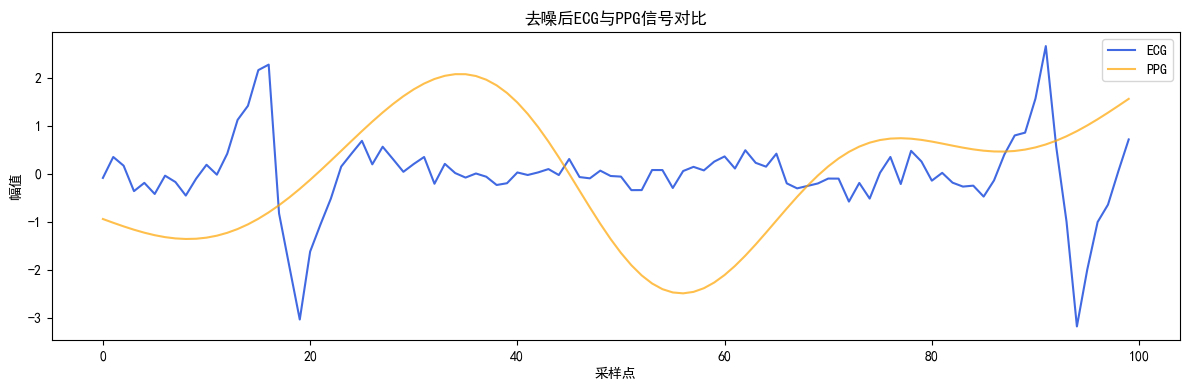

In [11]:
# 将去噪后的ecg、ppg信号放在一张图中
idx = 3
ecg = df.iloc[idx]["normalized_ecg"][0:100]
ppg = df.iloc[idx]["normalized_ppg"][0:100]

plt.figure(figsize=(12, 4))
plt.plot(ecg, label="ECG", color="royalblue")
plt.plot(ppg, label="PPG", color="orange", alpha=0.7)
plt.xlabel("采样点")
plt.ylabel("幅值")
plt.legend()
plt.title("去噪后ECG与PPG信号对比")
plt.tight_layout()
plt.show()

In [12]:
# 构建特征和标签
df["ecg_ppg_diff"] = df.apply(
    lambda row: row["normalized_ecg"] - row["normalized_ppg"], axis=1
)
X = np.stack(df["ecg_ppg_diff"].values)
y_sbp = df["hbp"].values
y_dbp = df["lbp"].values
print("特征形状：", X.shape)
print("收缩压标签形状：", y_sbp.shape)


X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
y_sbp_tensor = torch.tensor(y_sbp, dtype=torch.float32).unsqueeze(1)
y_dbp_tensor = torch.tensor(y_dbp, dtype=torch.float32).unsqueeze(1)

特征形状： (3732, 2500)
收缩压标签形状： (3732,)


In [13]:
# 数据集划分
from sklearn.model_selection import train_test_split

X_train, X_val, y_sbp_train, y_sbp_val, y_dbp_train, y_dbp_val = train_test_split(
    X, y_sbp, y_dbp, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32).unsqueeze(1),
    torch.tensor(y_sbp_train, dtype=torch.float32).unsqueeze(1),
    torch.tensor(y_dbp_train, dtype=torch.float32).unsqueeze(1)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32).unsqueeze(1),
    torch.tensor(y_sbp_val, dtype=torch.float32).unsqueeze(1),
    torch.tensor(y_dbp_val, dtype=torch.float32).unsqueeze(1)
)

dataset = TensorDataset(X_tensor, y_sbp_tensor, y_dbp_tensor)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [14]:
model = BPNet()
from torchinfo import summary
summary(model, input_size=(8, 1, 2500), device="cpu")

Layer (type:depth-idx)                   Output Shape              Param #
BPNet                                    [8, 1]                    --
├─Sequential: 1-1                        [8, 128, 312]             --
│    └─ConvBlock: 2-1                    [8, 32, 1250]             --
│    │    └─Conv1d: 3-1                  [8, 32, 2500]             192
│    │    └─ReLU: 3-2                    [8, 32, 2500]             --
│    │    └─BatchNorm1d: 3-3             [8, 32, 2500]             64
│    │    └─MaxPool1d: 3-4               [8, 32, 1250]             --
│    └─ConvBlock: 2-2                    [8, 64, 625]              --
│    │    └─Conv1d: 3-5                  [8, 64, 1250]             10,304
│    │    └─ReLU: 3-6                    [8, 64, 1250]             --
│    │    └─BatchNorm1d: 3-7             [8, 64, 1250]             128
│    │    └─MaxPool1d: 3-8               [8, 64, 625]              --
│    └─ConvBlock: 2-3                    [8, 128, 312]             --
│    │   

In [16]:
# 设备
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [17]:
# 模型、损失、优化器
model = BPNet(in_channels=1).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 500
MODEL_SAVE_PATH = "bpnet_best.pth"
PATIENCE = 50
best_val_loss = float("inf")
epochs_no_improve = 0

train_loss_curve = []
val_loss_curve = []

In [18]:
# 训练
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb_sbp, yb_dbp in loader:
        xb = xb.to(DEVICE)
        yb = torch.cat([yb_sbp, yb_dbp], dim=1).to(DEVICE)  # (B,2)
        optimizer.zero_grad()
        pred_sbp, pred_dbp = model(xb)
        preds = torch.cat([pred_sbp, pred_dbp], dim=1)  # (B,2)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)
    train_loss_curve.append(avg_train_loss)

    # 验证
    model.eval()
    val_losses = []
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb_sbp, yb_dbp in loader:
            xb = xb.to(DEVICE)
            yb = torch.cat([yb_sbp, yb_dbp], dim=1).to(DEVICE)
            pred_sbp, pred_dbp = model(xb)
            preds = torch.cat([pred_sbp, pred_dbp], dim=1)
            loss = criterion(preds, yb)
            val_losses.append(loss.item())
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    avg_val_loss = np.mean(val_losses)
    val_loss_curve.append(avg_val_loss)

    preds_np = np.vstack(all_preds) if all_preds else np.empty((0, 2))
    targets_np = np.vstack(all_targets) if all_targets else np.empty((0, 2))

    # 计算 MAE, RMSE, R2
    if preds_np.shape[0] > 0:
        sbp_mae = np.mean(np.abs(preds_np[:, 0] - targets_np[:, 0]))
        dbp_mae = np.mean(np.abs(preds_np[:, 1] - targets_np[:, 1]))
        sbp_rmse = np.sqrt(np.mean((preds_np[:, 0] - targets_np[:, 0]) ** 2))
        dbp_rmse = np.sqrt(np.mean((preds_np[:, 1] - targets_np[:, 1]) ** 2))
        sbp_r2 = r2_score(targets_np[:, 0], preds_np[:, 0])
        dbp_r2 = r2_score(targets_np[:, 1], preds_np[:, 1])
    else:
        sbp_mae = dbp_mae = sbp_rmse = dbp_rmse = sbp_r2 = dbp_r2 = float("nan")

    print(
        f"Epoch {epoch:03d} | TrainLoss {avg_train_loss:.6f} | ValLoss {avg_val_loss:.6f} | "
        f"SBP MAE {sbp_mae:.3f} RMSE {sbp_rmse:.3f} R2 {sbp_r2:.3f} | "
        f"DBP MAE {dbp_mae:.3f} RMSE {dbp_rmse:.3f} R2 {dbp_r2:.3f}"
    )

    # early stopping & save best
    if avg_val_loss < best_val_loss - 1e-6:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(
            {
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "epoch": epoch,
                "val_loss": best_val_loss,
            },
            MODEL_SAVE_PATH,
        )
        print("  -> Saved best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch}, no improvement for {PATIENCE} epochs."
            )
            break

Epoch 001 | TrainLoss 405.675878 | ValLoss 277.003311 | SBP MAE 16.303 RMSE 19.667 R2 -0.037 | DBP MAE 10.621 RMSE 12.920 R2 -0.156
  -> Saved best model
Epoch 002 | TrainLoss 254.075054 | ValLoss 228.650357 | SBP MAE 14.757 RMSE 17.997 R2 0.131 | DBP MAE 9.353 RMSE 11.562 R2 0.074
  -> Saved best model
Epoch 003 | TrainLoss 243.811515 | ValLoss 207.468734 | SBP MAE 13.474 RMSE 17.083 R2 0.218 | DBP MAE 8.840 RMSE 11.108 R2 0.145
  -> Saved best model
Epoch 004 | TrainLoss 228.752979 | ValLoss 210.046565 | SBP MAE 13.321 RMSE 16.499 R2 0.270 | DBP MAE 9.469 RMSE 12.169 R2 -0.026
Epoch 005 | TrainLoss 218.219129 | ValLoss 187.920918 | SBP MAE 12.586 RMSE 15.607 R2 0.347 | DBP MAE 9.382 RMSE 11.499 R2 0.084
  -> Saved best model
Epoch 006 | TrainLoss 197.311376 | ValLoss 156.177880 | SBP MAE 11.341 RMSE 14.282 R2 0.453 | DBP MAE 8.397 RMSE 10.416 R2 0.248
  -> Saved best model
Epoch 007 | TrainLoss 184.979107 | ValLoss 150.202978 | SBP MAE 11.358 RMSE 14.030 R2 0.472 | DBP MAE 8.243 RMSE

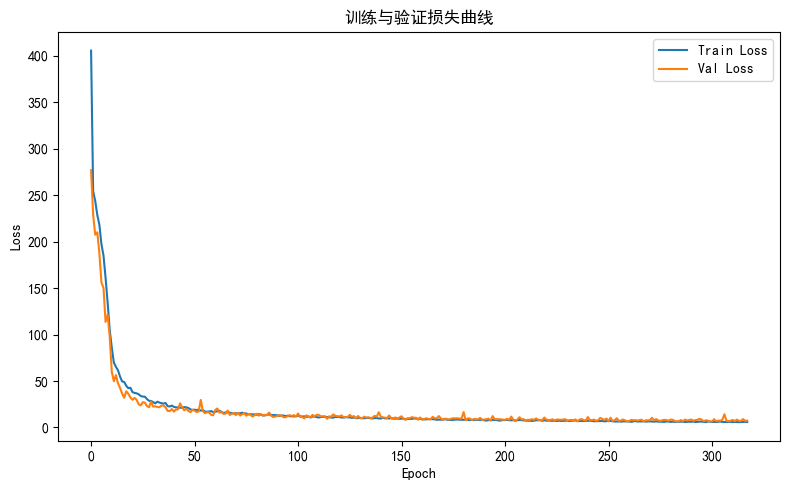

In [19]:
# 画出损失曲线
plt.figure(figsize=(8,5))
plt.plot(train_loss_curve, label="Train Loss")
plt.plot(val_loss_curve, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("训练与验证损失曲线")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# 预测误差
stable_epochs = 50
final_preds = preds_np[-stable_epochs:]
final_targets = targets_np[-stable_epochs:]

if final_preds.shape[0] > 0:
    avg_mae_sbp = np.mean(np.abs(final_preds[:, 0] - final_targets[:, 0]))
    avg_mae_dbp = np.mean(np.abs(final_preds[:, 1] - final_targets[:, 1]))
else:
    avg_mae_sbp = avg_mae_dbp = float('nan')

print(f"稳定时平均预测 SBP MAE: {avg_mae_sbp:.2f}")
print(f"稳定时平均预测 DBP MAE: {avg_mae_dbp:.2f}")

稳定时平均预测 SBP MAE: 2.59
稳定时平均预测 DBP MAE: 1.64
